# What Makes a Song Popular? An Exploratory Data Analysis of Spotify Audio Features

What characteristics are associated with popular songs on Spotify? To explore this question, we look at patterns connecting audio features, such as danceability and energy, to Spotify's popularity metric. Understanding these relationships can offer insight into listener behavior and online music trends. This is accomplished by examining both the univariate distributions of individual features and the bivariate relationships between those features and popularity, using cleaned data from the Spotify API.

In [1]:
 import pandas as pd
 import numpy as np
 import matplotlib.pyplot as plt
 import seaborn as sns
 import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

print("Path to dataset files:", path)


100%|██████████| 8.42M/8.42M [00:00<00:00, 102MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yashdev01/spotify-tracks-dataset/versions/1


In [2]:
import os
os.listdir(path)
os.path.join(path, "spotify-tracks-dataset.csv")

'/root/.cache/kagglehub/datasets/yashdev01/spotify-tracks-dataset/versions/1/spotify-tracks-dataset.csv'

This dataset comes from Spotify's API via Kaggle. Each row represents a different song, described by several audio features (such as danceability, energy, and valence) along with a popularity score. Popularity is an algorithmic, recency-weighted metric based mostly on recent play counts, so it reflects current streaming activity rather than a song's objective quality or all-time success. This is an important caveat to keep in mind when interpreting any relationship with popularity.

In [3]:
import os

csv_joined_path = os.path.join(path, "spotify-tracks-dataset.csv")
df = pd.read_csv(csv_joined_path)
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

Here I first work to understand the Spotify data and see what I'm working with. I begin by loading the data from Kaggle using their API, making sure the path to the data is accessible. To do this I use the `os` library to locate the path, then join that folder path with the file `spotify-tracks-dataset.csv`. This lets me access the file, which I then read into a dataframe. Observing this dataframe with `.head()`, `.describe()`, `.shape`, and `.info()` lets me see the story of the data: the number of data points I'm working with, the measured numerical values, their distributions, and unnecessary data that needs cleaning.

In [5]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [6]:
df.shape

(114000, 22)

Inspecting the data with `.describe()` and `.info()` surfaced several things. The dataset has ~114k rows and 22 columns, with one row missing text values and two redundant index columns. Duration and tempo both show impossible minimums of zero, flagging invalid records. Popularity ranges 0–100 with a median of 35 and a 25th percentile of 17, so while it leans toward lower values, it isn't dominated by zero-popularity songs. Several features, such as acousticness and instrumentalness, show large gaps between their median and mean, hinting at strong skew worth examining in the distributions below. These observations directly inform the cleaning and analysis that follow.

In [7]:
#cleaning
#Drops the first 2 columns
df_clean = df.drop(columns = ["Unnamed: 0.1", "Unnamed: 0"] )
#Drops NA data points
df_clean = df_clean.dropna()
#Drops zero values for duration and tempo columns
df_clean = df_clean[(df_clean["duration_ms"] > 0) & (df_clean["tempo"] > 0)]
#Drop duplicate songs across singles and albums
df_clean = df_clean.drop_duplicates(subset =  ["track_name", "artists"])





This section covers the data cleaning, approached in four steps.

1. I dropped the first two columns, "Unnamed: 0.1" and "Unnamed: 0," using `.drop()` and explicitly naming the columns to remove. These are redundant row-index counters that carry no analytical information.

2. I dropped rows containing NA values using `.dropna()`. Although pandas skips NAs when computing summary statistics rather than breaking, these empty points don't contribute to the analysis, create inconsistent counts across columns, and could break other tools I might run the cleaned data through.

3. I filtered out rows where duration_ms or tempo was zero, keeping only rows where both are greater than zero. A zero-second song or a song with zero BPM doesn't make sense in the real world, so these are invalid measurements. I used boolean masking with a combined condition rather than a loop, which is both faster and more readable.

4. Finally, I removed duplicate songs using the vectorized `.drop_duplicates()`, matching on track_name and artists. Songs are frequently duplicated across singles and albums, so treating a matching track_name and artist pair as a duplicate lets me keep one entry per unique song. Using the vectorized function let me avoid a manual loop, since it checks all rows for matching keys at once in optimized code.

## Analysis & Visualizations — Histograms

To begin, I use `.describe()` again on the cleaned data to get a numerical story before visualizing. The summary statistics below give a first sense of each feature's center and spread, which the histograms then make visual.

In [8]:
df_clean.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,81198.000000,8.119800e+04,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000,81198.000000
mean,34.631752,2.315081e+05,0.560274,0.635945,5.285881,-8.569006,0.632257,0.089152,0.329309,0.183896,0.219321,0.464104,122.362955,3.903926
std,19.449542,1.152321e+05,0.176326,0.257756,3.556914,5.260234,0.482194,0.116672,0.339725,0.330901,0.197740,0.262889,29.710068,0.426032
min,0.000000,1.580000e+04,0.051300,0.000020,0.000000,-46.591000,0.000000,0.022100,0.000000,0.000000,0.009250,0.000000,30.200000,0.000000
25%,21.000000,1.740000e+05,0.447000,0.456250,2.000000,-10.427000,0.000000,0.036100,0.015900,0.000000,0.098500,0.242000,99.659000,4.000000
50%,35.000000,2.153050e+05,0.574000,0.678000,5.000000,-7.253500,1.000000,0.049200,0.190000,0.000087,0.133000,0.449000,122.047500,4.000000
75%,49.000000,2.674280e+05,0.690000,0.857000,8.000000,-5.137000,1.000000,0.087200,0.629000,0.149000,0.282000,0.676000,140.146750,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Next, I wanted to see all the variables visually in order to identify the appropriate ones to analyze. I do this by examining each variable's distribution through histograms. This lets me visually catch symmetry, skews, bimodal peaks, or any other distribution shape within the variables.

array([[<Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>],
       [<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'time_signature'}>, <Axes: >, <Axes: >]],
      dtype=object)

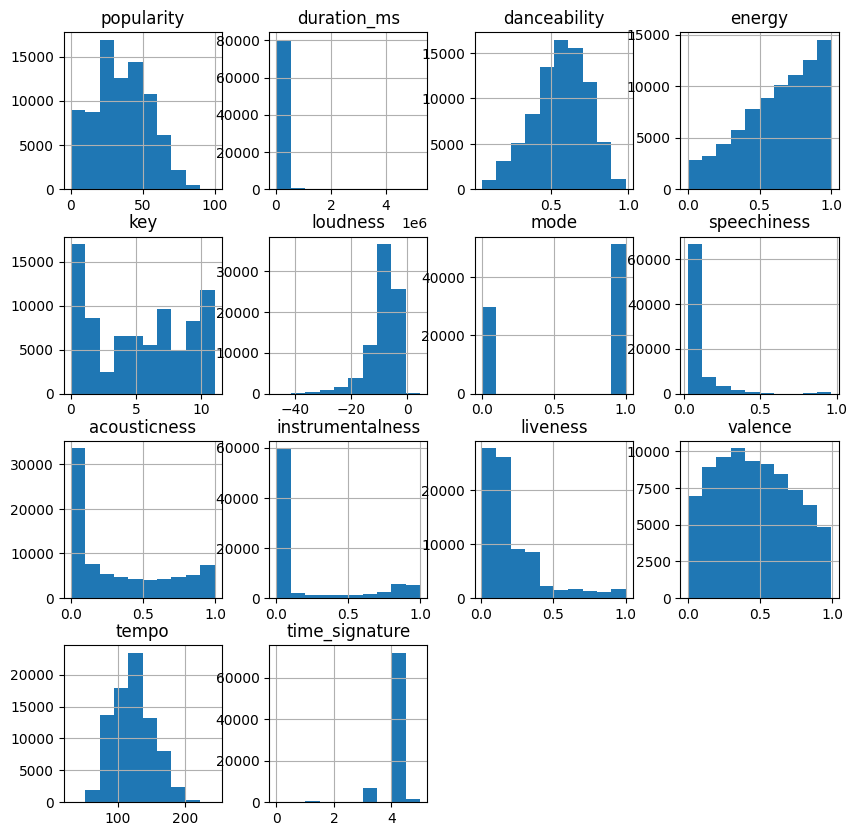

In [9]:
df_clean.hist(figsize= (10,10))

Here are all numeric distributions. I examined every distribution but chose to focus on popularity, since it is the target, along with a select few features that span different distribution types: symmetric, left-skewed, and heavily right-skewed. This avoids repeating near-identical analysis across all eleven variables.

array([[<Axes: title={'center': 'popularity'}>]], dtype=object)

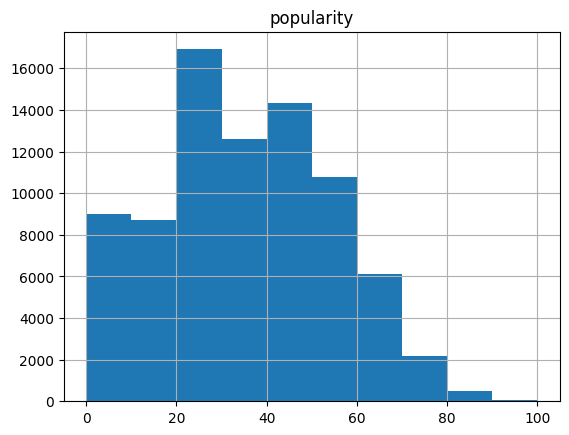

In [10]:
df_clean.hist(column= "popularity")


**Figure 1:**
Here the histogram visually represents the distribution of popularity. From the numerical data, the mean (34.631) and the median (35) are nearly the same. This 0.4 difference has only a small impact on the distribution, as we can see from the histogram, which is mildly right-leaning and roughly centered. The bulk of the popularity data sits between 20 and 50, with a peak between 20 and 30 and a steep decline after 60 followed by a tail approaching 100. The distribution could suggest a possible secondary peak between 40 and 50. This indicates that the majority of songs do not shoot to the top of the popularity charts, as shown by the bulk of the data falling between 20 and 50. This is further supported by the sparse amount of songs that reach popular status, greater than 60, represented by the declining tail toward 100. This roughly symmetric distribution means the target data is fairly well behaved, allowing for direct analysis without transformation.

array([[<Axes: title={'center': 'energy'}>]], dtype=object)

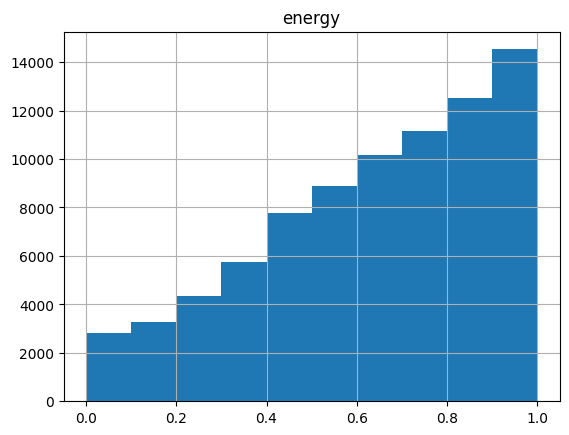

In [11]:
df_clean.hist(column= "energy")


**Figure 2:**
Here the histogram shows the distribution of energy in the Spotify data. Spotify defines energy as the perceived intensity and activity of a song, measured on a 0–1 scale. The mean is 0.635945 and the median 0.678000. Because the median is 0.042 larger than the mean, we see a clear left-skewed distribution, appearing as a long tail gently extending to the left. This indicates a minority of songs are low-energy while the majority are energetic. This skew means any relationship between energy and popularity is assessed across a range where energetic music dominates. Additionally, because the skew is gentle and continuous rather than clustered at the extremes, the correlation between energy and popularity remains fairly trustworthy for analysis.

array([[<Axes: title={'center': 'danceability'}>]], dtype=object)

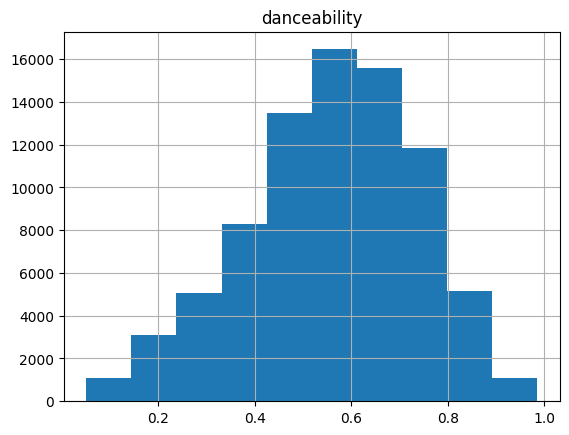

In [12]:
df_clean.hist(column= "danceability")


**Figure 3:**
Here the histogram displays the danceability of a song. Danceability is a composite metric, according to Spotify, that judges how danceable a song is based on tempo, rhythm stability, beat strength, and regularity. It is measured on a 0–1 scale, zero being least danceable and one being most. Numerically, the mean (0.560274) and median (0.574000) are nearly equal, differing by about 0.014. With near equivalence, we expect a bell-like distribution, which we do see, with a peak between 0.55 and 0.65 at the center of the data. There is no distinct skew; the shape is roughly symmetric. This symmetry means danceability's correlation values can be trusted without the caution the skewed features require, making it a clean baseline to compare the more heavily skewed distributions against.

array([[<Axes: title={'center': 'acousticness'}>]], dtype=object)

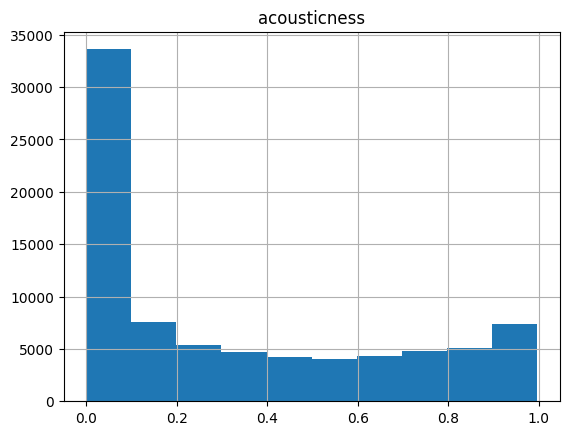

In [13]:
df_clean.hist(column= "acousticness")

**Figure 4:**
Here this histogram shows acousticness, a 0–1 metric measuring the confidence that a song is acoustic. There is a massive spike from 0.0–0.1, over 33,000 songs, which then falls dramatically with a small peak as we approach 1.0. The mean (0.33) sits well above the median (0.19). This large low-end build-up drags the median down while the spread of data pulls the mean up. This dramatic skew indicates that a large amount of songs, roughly 33,000, have very low acousticness confidence. This clumping distribution with a sparse middle is exactly the kind of shape that can make a linear correlation misleading, so further analysis with a scatterplot will be needed to verify any correlation acousticness shows with popularity.

## Analysis & Visualizations — Heatmaps and Scatterplots

In [14]:
#first create the subset
df_subset = df_clean[["popularity", "acousticness", "danceability", "energy", "instrumentalness", "liveness", "loudness", "speechiness", "tempo", "valence"]]
df_subset.columns

Index(['popularity', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence'],
      dtype='object')

In [15]:
#create the correlation matrix
corr_matrix = df_subset.corr()
corr_matrix

,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
popularity,1.000000,-0.032255,0.088813,-0.000429,-0.175541,-0.029294,0.091686,-0.064785,0.002903,0.011780
acousticness,-0.032255,1.000000,-0.166266,-0.733362,0.094242,-0.016737,-0.583894,0.013144,-0.222990,-0.100297
danceability,0.088813,-0.166266,1.000000,0.125107,-0.185791,-0.127994,0.254756,0.104993,-0.039171,0.487919
energy,-0.000429,-0.733362,0.125107,1.000000,-0.183004,0.195895,0.761382,0.137773,0.251200,0.249458
instrumentalness,-0.175541,0.094242,-0.185791,-0.183004,1.000000,-0.100722,-0.433594,-0.105440,-0.049590,-0.329827
liveness,-0.029294,-0.016737,-0.127994,0.195895,-0.100722,1.000000,0.084248,0.234130,-0.000634,0.018106
loudness,0.091686,-0.583894,0.254756,0.761382,-0.433594,0.084248,1.000000,0.050933,0.220256,0.285115
speechiness,-0.064785,0.013144,0.104993,0.137773,-0.105440,0.234130,0.050933,1.000000,-0.008868,0.032785
tempo,0.002903,-0.222990,-0.039171,0.251200,-0.049590,-0.000634,0.220256,-0.008868,1.000000,0.081830
valence,0.011780,-0.100297,0.487919,0.249458,-0.329827,0.018106,0.285115,0.032785,0.081830,1.000000


Here is the correlation matrix of the cleaned Spotify data. A correlation matrix provides a value called the correlation coefficient that shows how each feature relates to the others. In this case, I am looking at how each song feature relates to popularity. This value ranges from −1 to +1: positive one means a positive linear relationship, negative one means the opposite, and zero indicates no relationship. We can immediately see that no variable has a strong correlation with popularity across the board. This indicates that no single variable is strongly associated with popularity on its own. To better represent these values visually, I generate a heatmap below.

<Figure size 1000x800 with 0 Axes>

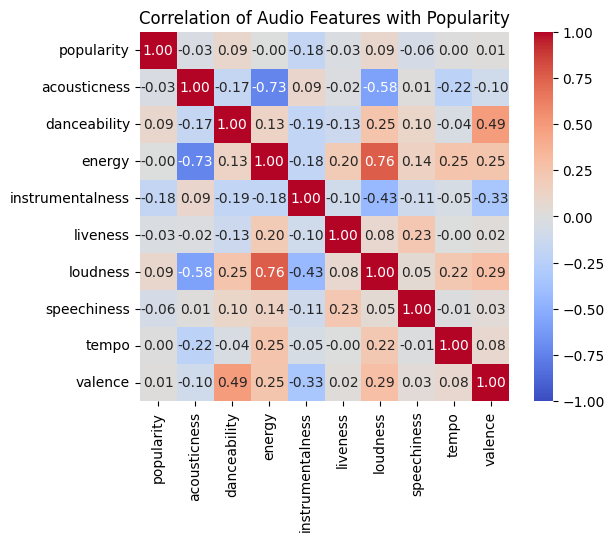

<Figure size 1000x800 with 0 Axes>

In [16]:
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", vmin=-1, vmax=1,
            center=0, fmt='.2f', square=True)
plt.title("Correlation of Audio Features with Popularity")
plt.figure(figsize=(10,8))

Here the heatmap is a visual representation of the correlation matrix. As mentioned above, no single variable is strongly associated with popularity. The highest absolute correlation is instrumentalness at −0.18, which is notable given its skewed distribution and suggests potential non-linearity worth checking. Another unexpected result is energy at −0.0004, essentially zero. Energy is often assumed to drive popularity, but here we observe no connection at all. We also see weak positive correlations for danceability and loudness, which are likely more reliable indicators because of their relatively symmetric distributions. I examine these variables in further detail with scatterplots and boxplots to verify their values and check for any hidden non-linear patterns. Two inter-feature values are also worth acknowledging: the strong positive correlation between energy and loudness (0.76) and the negative correlation between energy and acousticness (−0.73). These match intuition, since higher energy tends to mean louder and less acoustic music, and it is satisfying to see it confirmed here. Notably, given the strong correlation between energy and loudness, you might expect them to affect popularity similarly, but as the values above show, only loudness has a link, which is something to look into in the future.

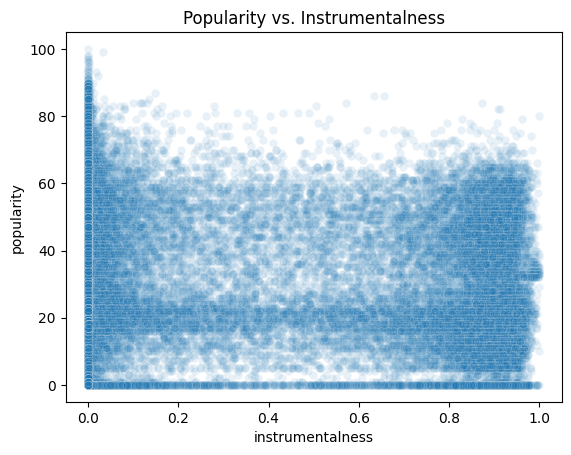

In [17]:
## remember to do a binned boxplot
sns.scatterplot(data=df_clean, x="instrumentalness", y="popularity", alpha=0.1,)
plt.title("Popularity vs. Instrumentalness")
plt.show()

In order to verify the instrumentalness correlation of −0.18, I use a scatterplot to visualize the relationship between popularity and instrumentalness. Here we see a massive spread of data with a few slight trends. First, there are two clumps of data points around 0 and 1. These clusters represent the large amount of songs at these extremes revealed by the histogram. Additionally, between 0.2 and 0.8 we observe a sparse, thin density of points. This reflects the histogram's drastic drop and tail-like behavior between the extremes. There is also a slight downward movement in the point density, faintly suggesting a negative relationship, though the bimodal shape makes this hard to read from the scatter alone, which motivates the boxplot below. Two other features stand out: a vertical wall at instrumentalness ≈ 0, songs with vocals spanning all popularity levels, and a horizontal band at popularity ≈ 0, zero-popularity songs spanning all instrumentalness levels.

The two clumps at the extremes indicate bimodal behavior. This points to two distinct groups, vocal versus instrumental tracks, that may relate to popularity differently. To investigate further, I use boxplots to compare popularity across low, medium, and high instrumentalness scores.

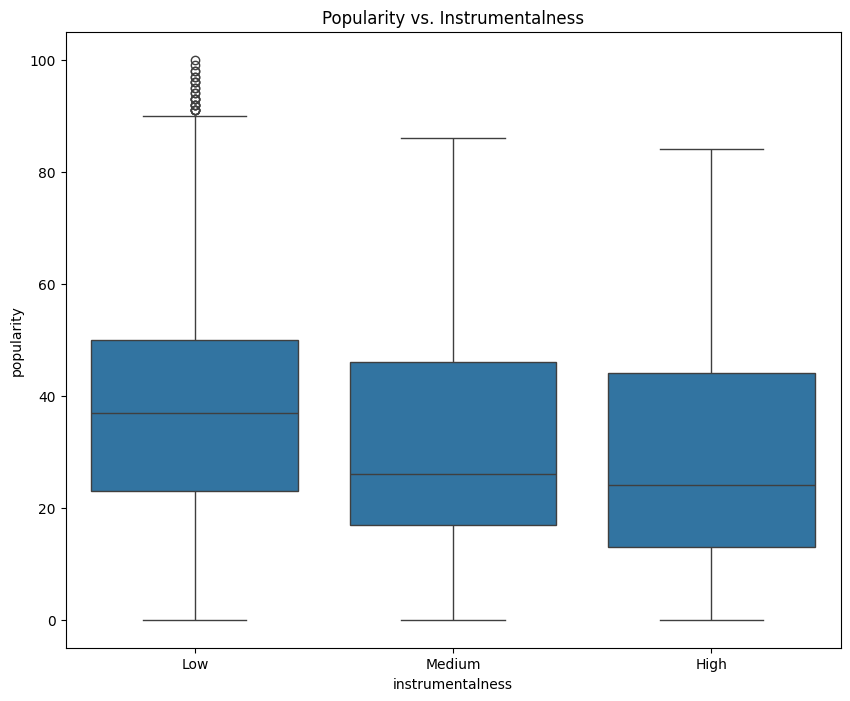

/tmp/ipykernel_3052/1431611255.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean["popularity"].groupby(intsrumental_group).describe()


,count,mean,std,min,25%,50%,75%,max
instrumentalness,,,,,,,,
Low,63401.0,36.355893,19.406381,0.0,23.0,37.0,50.0,100.0
Medium,3801.0,30.404367,18.367760,0.0,17.0,26.0,46.0,86.0
High,13996.0,27.969563,18.284847,0.0,13.0,24.0,44.0,84.0


In [18]:
intsrumental_group = pd.cut(df_clean["instrumentalness"],
       bins=[0,0.33,0.66,1.0],
       labels=['Low', 'Medium', 'High'], include_lowest=True)
plt.figure(figsize=(10,8))
sns.boxplot(x=intsrumental_group, y=df_clean["popularity"])
plt.title("Popularity vs. Instrumentalness")
plt.show()
df_clean["popularity"].groupby(intsrumental_group).describe()


The boxplots confirm a downward trend in popularity as instrumentalness increases. The medians drop clearly across groups, with Low at 37.0, Medium at 26.0, and High at 24.0, verifying the negative correlation. The same downward shift appears in each box's middle 50%, the 25th to 75th percentile range, so the drop isn't just in the medians but across the bulk of each group. Notably, the roughly 13-point median gap between Low and High is a meaningful difference on a 0–100 scale, even though the linear correlation of −0.18 appeared weak. The bimodal shape of instrumentalness likely masked the relationship's strength in the correlation alone, while grouping reveals it more clearly. This faintly but consistently affirms that vocal tracks, those with low instrumentalness, tend to be more popular than instrumental ones. The Medium group is comparatively small, at roughly 3,800 songs, so its estimate is less stable than the others.

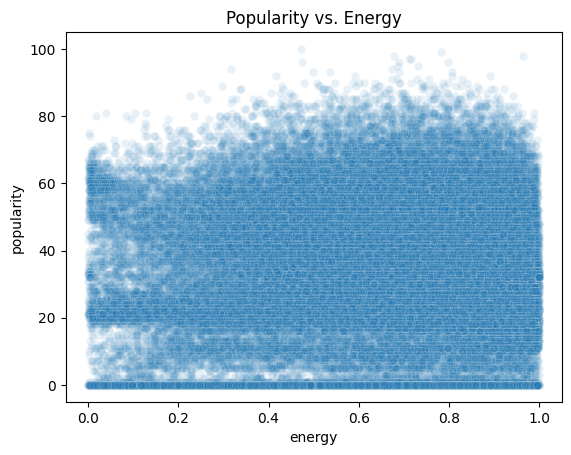

In [19]:
sns.scatterplot(data=df_clean, x='energy', y='popularity', alpha=0.1)
plt.title("Popularity vs. Energy")
plt.show()

Here is a scatterplot used to verify the unexpected near-zero correlation for energy in relation to popularity. From 0.0 to 1.0 the density of points stays relatively constant. Across the range we see a rectangle of points with no real change in density as energy increases or decreases. While it may appear slightly less dense at lower energy levels, the general trend shows no apparent linear relationship, and no visible curvature or arching that the correlation coefficient might have missed. With no visible trend, this confirms energy has essentially no relationship with popularity. This is a genuinely surprising result, as energy is commonly associated with popular music, yet the data shows otherwise.

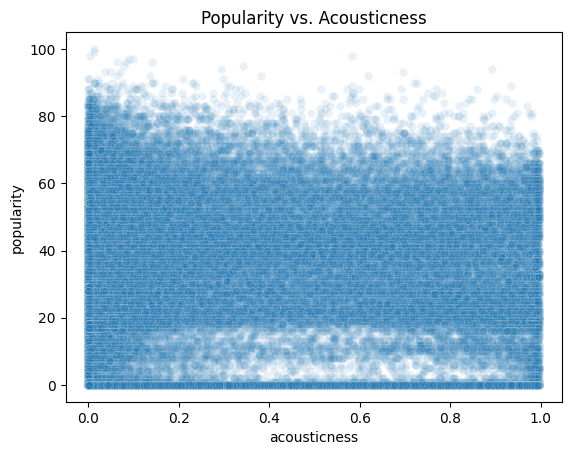

In [20]:
sns.scatterplot(data=df_clean, x='acousticness', y='popularity', alpha=0.1)
plt.title("Popularity vs. Acousticness")
plt.show()

Here this scatterplot is used to verify the negligible negative correlation for acousticness. Observing the point density, we see a rectangle of points, meaning no change in density as acousticness increases or decreases. This confirms the near-zero −0.03 correlation reflects faint to no association with popularity. However, looking at the cloud more closely, the left side appears more solid, the center (0.2–0.8) is sparser, and there is a slight increase in density at the right around 1.0. This matches what the histogram revealed, since acousticness has a stark right-skewed distribution, which shows up here as this variation in density. Importantly, this variation is in the feature's own distribution, not in its relationship with popularity, which remains flat.

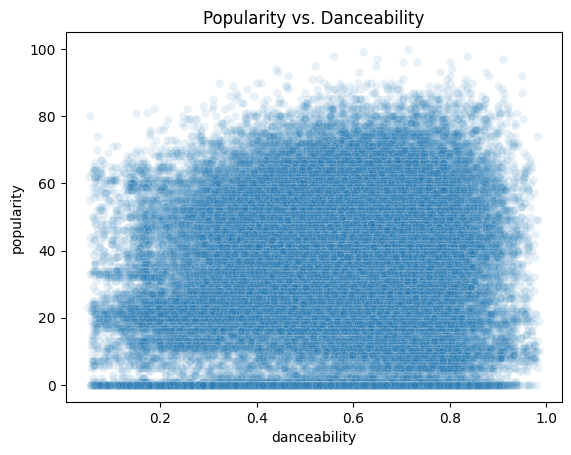

In [21]:
sns.scatterplot(data=df_clean, x='danceability', y='popularity', alpha=0.1)
plt.title("Popularity vs. Danceability")
plt.show()

Here this scatterplot is used to verify the faint positive correlation for danceability. Observing the point density, at low danceability the points collect lower, around 10–30 popularity. As danceability increases toward 0.6–0.8, the density shifts upward, indicating higher popularity. This upward tilt in the point cloud affirms the faint positive correlation of 0.09. It is worth noting how the univariate and bivariate views work together here: because danceability has a relatively symmetric distribution, its correlation value isn't distorted by skew, so we can trust the 0.09 more than a skewed feature's value, and the scatterplot then visually confirms the relationship itself.

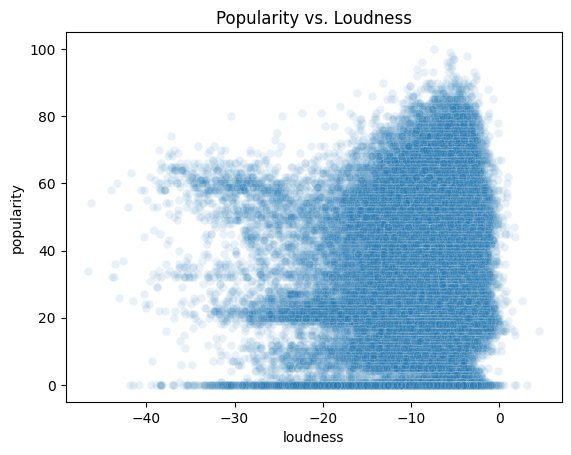

In [22]:
sns.scatterplot(data=df_clean, x='loudness', y='popularity', alpha=0.1)
plt.title("Popularity vs. Loudness")
plt.show()

Here this scatterplot verifies another faint positive correlation, this time for loudness, though it looks very different from danceability's. The main collection of points sits from −20 to 0 dB, while from −40 to −20 the density is sparse. This spread is intuitive: there are relatively few quiet songs, so tracks from −40 to −20 dB are rarer than louder ones, and the majority clump around −20 to −10 dB. More importantly for the correlation, as loudness increases from −40 toward 0, the cloud fans upward: quiet songs are almost all low-popularity, while louder songs reach higher popularity levels. This upward fan visually confirms the positive correlation of 0.09, and notably the relationship reads more clearly here than it did for danceability.

## Conclusion

From my findings, no single feature within a song has a strong relationship with popularity. Across the board, the strongest signals are weak. The strongest is instrumentalness, with a −0.18 correlation and an additional 13-point median gap indicating a lean toward vocal music being more popular. Among the faint positives, danceability and loudness both sit at 0.09, with loudness's scatterplot showing a clearer positive lean than its correlation value suggests. A surprising finding was energy's near-zero correlation, despite the common assumption that energetic songs are more popular.

Viewed collectively, a common trend emerges: the correlation values are all in proximity to zero. This points to the larger conclusion that popularity is not meaningfully explained by a song's measurable audio features. It leads me to believe songs are more significantly impacted by factors outside this dataset, such as artist popularity, marketing, playlists, and release timing. The contents of a song appear to have less to do with popularity than these outside factors.

A few intriguing findings stood out. Energy and loudness are strongly correlated with each other at 0.76, yet only loudness appears to have a link with popularity. This may suggest that the volume intensity tied to production has a link to popularity, more so than the broader, more generic term "energy." Additionally, the instrumentalness boxplot revealed a relationship more clearly than the correlation coefficient alone, indicating that a weak linear correlation does not always mean a definitively weak relationship.

## Limitations & Future Work

There are a few limitations to consider in this analysis. Popularity is an algorithmic, recency-weighted score that reflects recent streaming rather than quality or all-time success. Additionally, correlation only captures linear relationships; it cannot detect non-linear ones, though I mitigated this by checking key features with scatterplots. Finally, this dataset only includes audio features. There is no data on outside drivers such as artist fame, marketing, or playlist placement. These factors likely have a stronger relationship to popularity than the audio features analyzed here.

As for future directions, I would like to incorporate these outside factors to test the inference I drew in my conclusion. I would also like to explore whether certain genres, and their characteristic sets of audio features, correlate with popularity.